In [1]:
#Load Returns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

returns = pd.read_csv(PROCESSED_DIR / "returns_daily.csv", index_col="Date", parse_dates=True)

returns.head()

,NVDA,MSFT,JNJ,JPM,RTX,V
Date,,,,,,
2014-01-03,-0.011980,-0.006727,0.009008,0.007731,0.003644,0.000679
2014-01-06,0.013401,-0.021133,0.005226,0.005796,-0.000974,-0.006014
2014-01-07,0.016373,0.007750,0.021228,-0.011526,0.006384,0.007642
2014-01-08,0.013631,-0.017852,-0.001378,0.009431,0.001233,0.003205
2014-01-09,-0.037286,-0.006432,0.006053,-0.001869,0.000528,-0.001395


In [2]:
#Compute Summary Statistics
trading_days = 252

mean_daily = returns.mean()
mean_annual = mean_daily * trading_days

vol_daily = returns.std()
vol_annual = vol_daily * np.sqrt(trading_days)

summary = pd.DataFrame({
    "Annual Return": mean_annual,
    "Annual Volatility": vol_annual,
    "Sharpe (rf=0)": mean_annual / vol_annual
})

summary.sort_values("Annual Volatility")

,Annual Return,Annual Volatility,Sharpe (rf=0)
JNJ,0.084805,0.177622,0.477446
V,0.194904,0.241595,0.806739
RTX,0.102158,0.259617,0.393496
MSFT,0.273520,0.265028,1.032045
JPM,0.191236,0.266466,0.717675
NVDA,0.647818,0.469662,1.379329


In [3]:
#Covariance & Correlation
cov_matrix = returns.cov() * trading_days
corr_matrix = returns.corr()

cov_matrix

,NVDA,MSFT,JNJ,JPM,RTX,V
NVDA,0.220582,0.073523,0.014509,0.041641,0.033340,0.051927
MSFT,0.073523,0.070240,0.017925,0.031143,0.025949,0.038993
JNJ,0.014509,0.017925,0.031550,0.018895,0.017736,0.018429
JPM,0.041641,0.031143,0.018895,0.071004,0.040841,0.036899
RTX,0.033340,0.025949,0.017736,0.040841,0.067401,0.034239
V,0.051927,0.038993,0.018429,0.036899,0.034239,0.058368


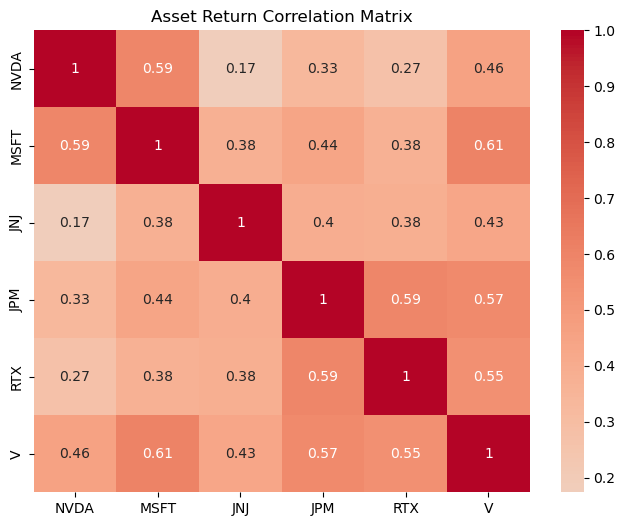

In [4]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Asset Return Correlation Matrix")
plt.show()

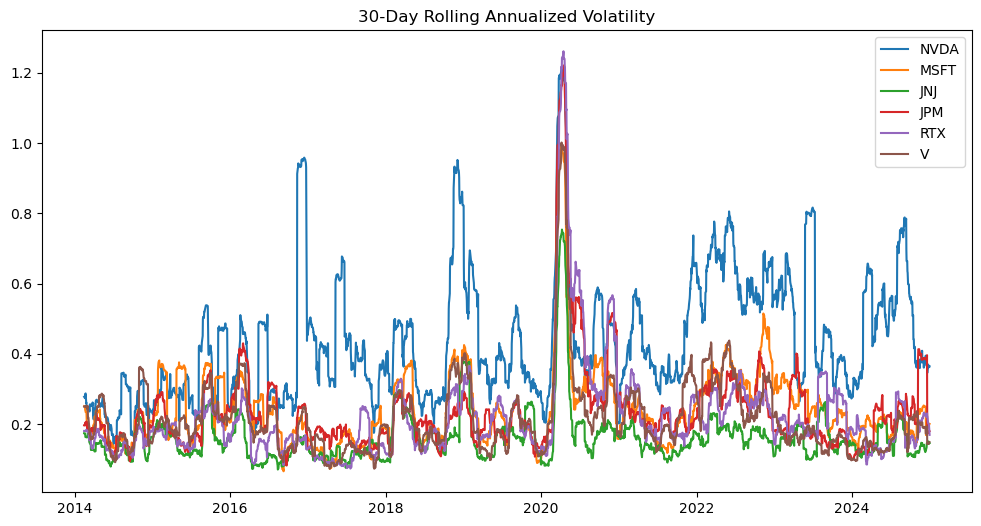

In [5]:
#Rolling Volatility
rolling_vol = returns.rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(12,6))
for col in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[col], label=col)

plt.legend()
plt.title("30-Day Rolling Annualized Volatility")
plt.show()